# scitex.io -- Unified File I/O (30+ Formats)

A single `save()`/`load()` interface that dispatches on file extension.
DataFrames, arrays, dicts, figures, configs -- all through one API.

In [1]:
%matplotlib inline
import scitex as stx
import numpy as np
import pandas as pd
import os

# Temp directory for demo files
os.makedirs("/tmp/scitex_io_demo", exist_ok=True)

## Save and Load

`stx.io.save()` and `stx.io.load()` dispatch on the file extension.
No need to remember `pd.read_csv`, `np.save`, `json.dump`, etc.

In [2]:
# CSV: DataFrame round-trip
df = pd.DataFrame({"x": [1, 2, 3], "y": [4.0, 5.0, 6.0], "label": ["a", "b", "c"]})
stx.io.save(df, "/tmp/scitex_io_demo/data.csv")

loaded_df = stx.io.load("/tmp/scitex_io_demo/data.csv")
print(loaded_df)

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/data.csv (34.0 B)


   x    y label
0  1  4.0     a
1  2  5.0     b
2  3  6.0     c


In [3]:
# NPY: NumPy array round-trip
arr = np.random.randn(3, 4)
stx.io.save(arr, "/tmp/scitex_io_demo/matrix.npy")

loaded_arr = stx.io.load("/tmp/scitex_io_demo/matrix.npy")
print(f"Shape: {loaded_arr.shape}, dtype: {loaded_arr.dtype}")
print(np.allclose(arr, loaded_arr))  # True

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/matrix.npy (224.0 B)


Shape: (3, 4), dtype: float64
True


In [4]:
# YAML: Dict round-trip
config = {"model": "resnet50", "epochs": 100, "lr": 0.001}
stx.io.save(config, "/tmp/scitex_io_demo/config.yaml")

loaded_config = stx.io.load("/tmp/scitex_io_demo/config.yaml")
print(loaded_config)

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/config.yaml (38.0 B)


{'model': 'resnet50', 'epochs': 100, 'lr': 0.001}


In [5]:
# JSON: Dict round-trip
metadata = {"subject": "sub-01", "sessions": [1, 2, 3], "valid": True}
stx.io.save(metadata, "/tmp/scitex_io_demo/metadata.json")

loaded_meta = stx.io.load("/tmp/scitex_io_demo/metadata.json")
print(loaded_meta)

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/metadata.json (103.0 B)


{'subject': 'sub-01', 'sessions': [1, 2, 3], 'valid': True}


In [6]:
# Pickle: arbitrary Python object round-trip
obj = {"nested": [1, 2, {"key": np.array([10, 20])}]}
stx.io.save(obj, "/tmp/scitex_io_demo/object.pkl")

loaded_obj = stx.io.load("/tmp/scitex_io_demo/object.pkl")
print(loaded_obj)

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/object.pkl (193.0 B)


{'nested': [1, 2, {'key': array([10, 20])}]}


## Figure with Auto CSV Export

When saving a figure through `stx.io.save()`, scitex automatically
exports the plotted data as a companion CSV file (e.g., `demo.csv`
alongside `demo.png`). This enables downstream reuse and verification.

INFO:   • Auto-collected metadata (editable v0.3 schema)


  Hitmap: /tmp/scitex_io_demo/demo_hitmap.png


INFO:   • Auto-cropped with 1.0mm margin (11px at 300 DPI)


Saved: /tmp/scitex_io_demo/demo.png + /tmp/scitex_io_demo/demo.yaml (Reproducible Validation: PASSED)


SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/demo.png (42.8 KiB) [W: 69.4mm, H: 54.4mm]


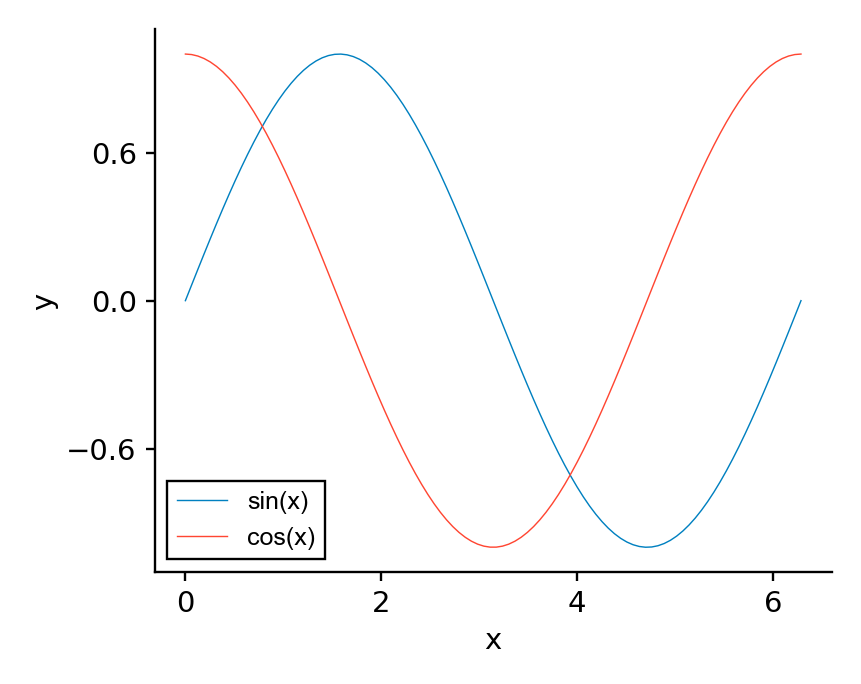

In [7]:
fig, ax = stx.plt.subplots()
x = np.linspace(0, 2 * np.pi, 100)
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

# Saves demo.png AND auto-generates demo.csv with the plotted data
stx.io.save(fig, "/tmp/scitex_io_demo/demo.png")
fig

## Custom Format Registration

Register your own savers and loaders for any extension.
The decorator-based API makes it trivial to add project-specific formats.

## Load Configs (YAML Aggregation)

`stx.io.load_configs()` aggregates all `./config/*.yaml` files into a single
`DotDict` with dot-notation access. This is what `@stx.session` uses internally
to build the `CONFIG` object.

In [8]:
# Create example config directory
config_dir = "/tmp/scitex_io_demo/config"
os.makedirs(config_dir, exist_ok=True)
stx.io.save({"hidden_size": 256, "n_layers": 4}, f"{config_dir}/MODEL.yaml")
stx.io.save({"epochs": 100, "batch_size": 32}, f"{config_dir}/TRAINING.yaml")

# Aggregate all YAML files in the directory into a single DotDict
CONFIG = stx.io.load_configs(config_dir=config_dir)
print(CONFIG)

# Dot-notation access
print(f"CONFIG.MODEL.hidden_size = {CONFIG.MODEL.hidden_size}")
print(f"CONFIG.TRAINING.epochs   = {CONFIG.TRAINING.epochs}")

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/config/MODEL.yaml (29.0 B)


SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/config/TRAINING.yaml (27.0 B)


{
    "MODEL": {
        "hidden_size": 256,
        "n_layers": 4
    },
    "TRAINING": {
        "epochs": 100,
        "batch_size": 32
    }
}
CONFIG.MODEL.hidden_size = 256
CONFIG.TRAINING.epochs   = 100


In [9]:
# Register custom format handlers via scitex_io directly
from scitex_io import register_saver, register_loader, save, load

@register_saver(".tsv_custom")
def save_tsv_custom(obj, path, **kw):
    """Save DataFrame as tab-separated with a comment header."""
    with open(path, "w") as f:
        f.write("# Custom TSV format\n")
        obj.to_csv(f, sep="\t", index=False)

@register_loader(".tsv_custom")
def load_tsv_custom(path, **kw):
    """Load tab-separated file, skipping comment lines."""
    return pd.read_csv(path, sep="\t", comment="#")

# Use registered handlers through scitex_io
save(df, "/tmp/scitex_io_demo/data.tsv_custom")
loaded = load("/tmp/scitex_io_demo/data.tsv_custom")
print(loaded)

SUCC: Saved to: ./../../../../../tmp/scitex_io_demo/data.tsv_custom (54.00 B)



   x    y label
0  1  4.0     a
1  2  5.0     b
2  3  6.0     c


## List Supported Formats

See every extension that scitex.io can handle out of the box.

In [10]:
# List all supported formats (savers and loaders)
stx.io.list_formats()

{'save': {'builtin': ['.bib',
   '.cbm',
   '.css',
   '.csv',
   '.gif',
   '.h5',
   '.hdf5',
   '.html',
   '.joblib',
   '.jpeg',
   '.jpg',
   '.js',
   '.json',
   '.mat',
   '.md',
   '.mp4',
   '.npy',
   '.npz',
   '.pdf',
   '.pickle',
   '.pkl',
   '.pkl.gz',
   '.png',
   '.pt',
   '.pth',
   '.py',
   '.svg',
   '.tex',
   '.tif',
   '.tiff',
   '.txt',
   '.xls',
   '.xlsx',
   '.yaml',
   '.yml',
   '.zarr'],
  'user': ['.tsv_custom']},
 'load': {'builtin': ['',
   '.bdf',
   '.bib',
   '.cnt',
   '.con',
   '.csv',
   '.db',
   '.docx',
   '.edf',
   '.eeg',
   '.egi',
   '.event',
   '.gdf',
   '.gz',
   '.h5',
   '.hdf5',
   '.joblib',
   '.jpg',
   '.json',
   '.log',
   '.mat',
   '.md',
   '.npy',
   '.npz',
   '.pdf',
   '.pickle',
   '.pkl',
   '.png',
   '.pt',
   '.pth',
   '.py',
   '.set',
   '.sh',
   '.tex',
   '.tif',
   '.tiff',
   '.tsv',
   '.txt',
   '.vhdr',
   '.vmrk',
   '.xls',
   '.xlsb',
   '.xlsm',
   '.xlsx',
   '.xml',
   '.yaml',
   '.yml',
 

## Cleanup

In [11]:
import shutil
os.chdir("/tmp")
shutil.rmtree("/tmp/scitex_io_demo", ignore_errors=True)
print("Cleaned up demo files.")

Cleaned up demo files.
